# 2018 OH-15 House Disaggregation

In [1]:
import pandas as pd
import geopandas as gpd
import re
from pathlib import Path

# ---- EDIT THESE PATHS to match your data/ folder ----
DATA = Path("../../data")

BEF_PATH   = DATA / "oh_cong_adopted_2025/October 31 2025 CD BAF.xlsx"      # new OH-15 boundary (block assignment)
MEDSL_PATH = DATA / "oh_medsl_18_general/oh_medsl_18_general.csv"  # MEDSL votes (has House election data, no geometry)
VEST_PATH = DATA / "oh_vest_18/oh_vest_18.shp"             # VEST precinct shapefile (geometry, no House election data)
P1_PATH = DATA / "oh_pl2020_b/oh_pl2020_p1_b.shp"          # 2020 census block population + geometry

TARGET_DISTRICT = 15
pd.set_option("display.max_columns", None)

In [2]:
# ---- Normalizing functions for precinct-name matching ----
# norm_vest cleans a name to a standard form ("COLS 12-D" → "cols 12 d")
# norm_medsl does the same plus removes the word "precinct" that MEDSL prepends ("PRECINCT BETH 1" → "beth 1") 

def norm_vest(s):
    """Normalize a VEST precinct name: lowercase, strip punctuation, collapse spaces."""
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def norm_medsl(s):
    """Same as norm_vest, but also strips MEDSL's leading 'precinct ' prefix."""
    s = str(s).lower().strip()
    s = re.sub(r"^precinct\s+", "", s)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

# Step 1 — Define the district
Load the official block-assignment file (BEF) and filter to District 15.
The resulting 16,658 census blocks *are* the new OH-15 boundary.

### New OH-15 boundary — the BEF block list

This defines the target geography. Every 2018 vote we eventually place has to land on these blocks.

In [3]:
# Load the full statewide block-to-district assignment
bef = pd.read_excel(BEF_PATH, dtype=str)  # force every column to be read as text
print("BEF columns:", list(bef.columns))
print("Shape:", bef.shape)
bef.head()

BEF columns: ['Block', 'DistrictID:1']
Shape: (276428, 2)


,Block,DistrictID:1
0,390159515003032,2
1,390159515003009,2
2,390159515003008,2
3,390159515003000,2
4,390159515002121,2


In [4]:
# Isolate District 15's block list. Column names in this file: 'Block' and 'DistrictID:1'.
# Adjust the column names here if your header differs.
block_col = "Block"
dist_col  = "DistrictID:1"

# -------------------------------------------------------------
# Get the block GEOID of every block assigned to District 15
# -------------------------------------------------------------
oh15_blocks = bef.loc[bef[dist_col].astype(str).str.strip() == str(TARGET_DISTRICT), block_col]
oh15_blocks = oh15_blocks.astype(str).str.strip()
print(f"OH-15 has {len(oh15_blocks):,} census blocks")
print("Sample GEOIDs:", oh15_blocks.head().tolist())
print("GEOID length(s):", sorted(oh15_blocks.str.len().unique()))  # expect 15, length of the ID strings

# -------------------------------------------------------------
# Get the Counties
# -------------------------------------------------------------
# County FIPS = chars 3-5 of a 15-digit block GEOID (state=39 Ohio, then 3-digit county)
oh15_counties = sorted(oh15_blocks.str[2:5].unique())
print(f"\nOH-15 spans {len(oh15_counties)} counties (by FIPS): {oh15_counties}")


OH-15 has 16,658 census blocks
Sample GEOIDs: ['390719552003056', '390719552003055', '390719552003054', '390719552003066', '390719552003053']
GEOID length(s): [15]

OH-15 spans 7 counties (by FIPS): ['023', '047', '049', '071', '097', '109', '129']


# Step 2 — Get 2018 votes with geography
2018 has no single file with House votes + precinct shapes, so we join two sources:
MEDSL (House votes, precinct names only) + VEST (precinct shapes, no House race),
matched on county + precinct name. Output: `placed_all` — precinct House votes with geometry.

### 2A. MEDSL 2018 U.S. House votes

This file is **long format**: one row per candidate × precinct × race. 


In [5]:
medsl = pd.read_csv(MEDSL_PATH, dtype=str) # keep FIPS codes and IDs as text
print("MEDSL columns:", list(medsl.columns))
print("Shape:", medsl.shape)
medsl.head()


MEDSL columns: ['Unnamed: 0', 'precinct', 'office', 'party_detailed', 'party_simplified', 'mode', 'votes', 'county_name', 'county_fips', 'jurisdiction_name', 'jurisdiction_fips', 'candidate', 'district', 'magnitude', 'dataverse', 'year', 'stage', 'state', 'special', 'writein', 'state_po', 'state_fips', 'state_cen', 'state_ic', 'date', 'readme_check']
Shape: (257219, 26)


,Unnamed: 0,precinct,office,party_detailed,party_simplified,mode,votes,county_name,county_fips,jurisdiction_name,jurisdiction_fips,candidate,district,magnitude,dataverse,year,stage,state,special,writein,state_po,state_fips,state_cen,state_ic,date,readme_check
0,531910,ADDYSTON A,US HOUSE,DEMOCRAT,DEMOCRAT,TOTAL,71,HAMILTON,39061,HAMILTON,39061.0,AFTAB PUREVAL,1,1.0,HOUSE,2018,GEN,OHIO,False,False,OH,39,31,24,2018-11-06,False
1,531911,ADDYSTON A,US HOUSE,LIBERTARIAN,LIBERTARIAN,TOTAL,5,HAMILTON,39061,HAMILTON,39061.0,DIRK KUBALA,1,1.0,HOUSE,2018,GEN,OHIO,False,False,OH,39,31,24,2018-11-06,False
2,531912,ADDYSTON A,US HOUSE,REPUBLICAN,REPUBLICAN,TOTAL,157,HAMILTON,39061,HAMILTON,39061.0,STEVE CHABOT,1,1.0,HOUSE,2018,GEN,OHIO,False,False,OH,39,31,24,2018-11-06,False
3,531913,CARLISLE VILLAGE 1-A,US HOUSE,DEMOCRAT,DEMOCRAT,TOTAL,66,WARREN,39165,WARREN,39165.0,AFTAB PUREVAL,1,1.0,HOUSE,2018,GEN,OHIO,False,False,OH,39,31,24,2018-11-06,False
4,531914,CARLISLE VILLAGE 1-A,US HOUSE,LIBERTARIAN,LIBERTARIAN,TOTAL,9,WARREN,39165,WARREN,39165.0,DIRK KUBALA,1,1.0,HOUSE,2018,GEN,OHIO,False,False,OH,39,31,24,2018-11-06,False


In [6]:
# What does MEDSL actually call these precincts (raw, pre-norm)?
fay_raw = medsl[(medsl["county_fips"]=="39047") & (medsl["dataverse"].str.lower()=="house")]
print("Fayette county_name:", fay_raw["county_name"].unique())
print("\nRaw MEDSL Fayette precinct names containing 'wash':")
print(sorted(fay_raw[fay_raw["precinct"].str.contains("ash", case=False, na=False)]["precinct"].unique()))

Fayette county_name: ['FAYETTE']

Raw MEDSL Fayette precinct names containing 'wash':
['WASHINGTON 1B', 'WASHINGTON 1C', 'WASHINGTON 2A', 'WASHINGTON 2D', 'WASHINGTON 3A', 'WASHINGTON 3D', 'WASHINGTON 3F', 'WASHINGTON 4A', 'WASHINGTON 4B', 'WASHINGTON 4C', 'WASHINGTON 4D']


In [7]:
# What offices / dataverses are present?
print("dataverse values:", medsl["dataverse"].unique())
print()

# Keep only the only the U.S. House rows
house = medsl[medsl["dataverse"].str.lower() == "house"].copy()
print(f"House rows: {len(house):,}")
print("\noffice values in house rows:", house["office"].unique())
print("\ndistrict values in house rows:", sorted(house["district"].unique()))

# These district numbers (1–16) are the old 2018 district lines. 
# Old district 15 ≠ new OH-15 (2026). This cell just inspects them; it doesn't filter by them.

dataverse values: ['HOUSE' 'SENATE' 'STATE']

House rows: 21,410

office values in house rows: ['US HOUSE']

district values in house rows: ['1', '10', '11', '12', '13', '14', '15', '16', '2', '3', '4', '5', '6', '7', '8', '9']


### 2B. VEST geometry — how feasible is the join?

MEDSL gives votes with precinct *names* but no shapes. VEST gives shapes but no House votes.
To put 2018 House results on a map (and then onto the new OH-15 blocks), we need to attach
MEDSL votes to VEST geometry via a **precinct-name + county** match — there's no shared ID.

This section measures how clean that match would be *before* you invest in building it.


In [8]:
vest = gpd.read_file(VEST_PATH)
print("VEST columns:", list(vest.columns))
print("Shape:", vest.shape)
print("CRS:", vest.crs)
vest.head()

VEST columns: ['STATEFP18', 'COUNTYFP18', 'VTDST18', 'PRECINCT18', 'GEOID18', 'NAME18', 'G18USSRREN', 'G18USSDBRO', 'G18GOVRDEW', 'G18GOVDCOR', 'G18GOVLIRV', 'G18GOVGGAD', 'G18ATGRYOS', 'G18ATGDDET', 'G18AUDRFAB', 'G18AUDDSPA', 'G18AUDLCOO', 'G18SOSRLAR', 'G18SOSDCLY', 'G18SOSLNAN', 'G18TRERSPR', 'G18TREDRIC', 'geometry']
Shape: (8912, 23)
CRS: epsg:4269


,STATEFP18,COUNTYFP18,VTDST18,PRECINCT18,GEOID18,NAME18,G18USSRREN,G18USSDBRO,G18GOVRDEW,G18GOVDCOR,G18GOVLIRV,G18GOVGGAD,G18ATGRYOS,G18ATGDDET,G18AUDRFAB,G18AUDDSPA,G18AUDLCOO,G18SOSRLAR,G18SOSDCLY,G18SOSLNAN,G18TRERSPR,G18TREDRIC,geometry
0,39,009,005ACR,ACR,39009005ACR,ATHENS 2-5,49,231,48,225,6,7,52,218,49,205,17,56,221,3,55,218,"POLYGON ((-82.09632 39.32211, -82.09627 39.322..."
1,39,017,009ACT,ACT,39017009ACT,HAMILTON PT1 WD4,100,274,108,253,7,5,112,249,111,250,13,108,256,11,116,256,"MULTIPOLYGON (((-84.54775 39.39416, -84.54760 ..."
2,39,017,009AFM,AFM,39017009AFM,TRENTON 6,331,151,341,126,15,3,344,128,335,116,27,342,123,16,350,128,"POLYGON ((-84.45731 39.48105, -84.45714 39.481..."
3,39,023,012ACN,ACN,39023012ACN,CITY 16,121,222,158,177,5,9,158,184,140,190,16,152,187,9,160,184,"POLYGON ((-83.84650 39.93574, -83.84644 39.935..."
4,39,023,012UAF,UAF,39023012UAF,PIKE 2,527,296,595,212,18,9,611,203,580,208,36,585,217,23,592,222,"POLYGON ((-83.99283 39.97934, -83.99282 39.979..."


In [9]:
# Do MEDSL numeric precinct IDs relate to VEST's VTD codes? NO, see Result note. 
# Franklin = FIPS 049 (your OH-15 core), good test county.

print("MEDSL precinct samples (Franklin):")
print(medsl[medsl["county_fips"] == "39049"]["precinct"].head(10).tolist())

print("\nVEST VTDST18 / GEOID18 samples (Franklin):")
fr = vest[vest["COUNTYFP18"] == "049"]
print(fr["VTDST18"].head(10).tolist())
print(fr["NAME18"].head(10).tolist())

# RESULT: No shared ID code. MEDSL numeric codes ≠ VEST VTDST18 codes.
# Both have readable names (MEDSL 'precinct', VEST 'NAME18') -> join on county + name.

MEDSL precinct samples (Franklin):
['BEXLEY 1-A', 'BEXLEY 1-A', 'BEXLEY 1-B', 'BEXLEY 1-B', 'BEXLEY 2-A', 'BEXLEY 2-A', 'BEXLEY 2-B', 'BEXLEY 2-B', 'BEXLEY 3-A', 'BEXLEY 3-A']

VEST VTDST18 / GEOID18 samples (Franklin):
['025AQN', '025BGB', '025AIH', '025BHA', '025AMY', '025ANZ', '025AOZ', '025AOG', '025BGU', '025BJN']
['COLS 72-C', 'COLS 76-A', 'COLS 41-D', 'COLS 77-B', 'COLS 59-D', 'COLS 63-E', 'COLS 67-C', 'COLS 64-B', 'COLS 76-B', 'COLS 69-H']


In [10]:
# How do the naming conventions differ in Franklin? Look at the leading tokens.

medsl_fr = set(medsl[medsl["county_fips"]=="39049"]["precinct"].map(norm_vest)) # using the "precinct" column
vest_fr   = set(vest[vest["COUNTYFP18"]=="049"]["NAME18"].map(norm_vest))       # using the "NAME18" column

print(f"MEDSL Franklin precincts: {len(medsl_fr)}")
print(f"VEST Franklin precincts:  {len(vest_fr)}")
print(f"Exact matches as-is:      {len(medsl_fr & vest_fr)}")
print()
# What leading words does each source use? (reveals COLUMBUS vs COLS etc.)
from collections import Counter
print("MEDSL leading tokens:", Counter(p.split()[0] for p in medsl_fr if p).most_common(10))
print("VEST leading tokens: ", Counter(p.split()[0] for p in vest_fr if p).most_common(10))

# RESULT: Franklin 863/863 exact match; both sources use identical naming (cols, ua, gah...). 

MEDSL Franklin precincts: 863
VEST Franklin precincts:  863
Exact matches as-is:      863

MEDSL leading tokens: [('cols', 534), ('ua', 31), ('gah', 30), ('grove', 27), ('dub', 27), ('westerville', 25), ('hill', 23), ('reyns', 22), ('worth', 14), ('prairie', 13)]
VEST leading tokens:  [('cols', 534), ('ua', 31), ('gah', 30), ('grove', 27), ('dub', 27), ('westerville', 25), ('hill', 23), ('reyns', 22), ('worth', 14), ('prairie', 13)]


In [11]:
# Confirm the exact-match rate across ALL 7 OH-15 counties, not just Franklin.

# OH-15 county FIPS from the BEF (section 1): 023,047,049,071,097,109,129
oh15_fips3 = ['023','047','049','071','097','109','129']

print(f"{'County':<8}{'MEDSL':>8}{'VEST':>8}{'Matched':>9}{'MEDSL-only':>12}{'VEST-only':>11}")
for fips in oh15_fips3:
    m = set(medsl[medsl["county_fips"]=="39"+fips]["precinct"].map(norm_vest))
    v = set(vest[vest["COUNTYFP18"]==fips]["NAME18"].map(norm_vest))
    matched = m & v
    print(f"{fips:<8}{len(m):>8}{len(v):>8}{len(matched):>9}{len(m-v):>12}{len(v-m):>11}")
    
# RESULT: 3 counties clean (049/071/097). 023/109 total name-mismatch, 047/129 partial. 
# Same counts, diff names = fixable convention issue, not missing data.

County     MEDSL    VEST  Matched  MEDSL-only  VEST-only
023           90      90        0          90         90
047           25      25       14          11         11
049          863     863      863           0          0
071           31      31       31           0          0
097           24      24       24           0          0
109           85      85        0          85         85
129           42      42        1          41         41


In [12]:
# What do the mismatched names look like? Compare MEDSL vs VEST side by side.
for fips, name in [("023","Clinton"), ("109","Madison"), ("129","Pickaway"), ("047","Fayette")]:
    m = sorted(medsl[medsl["county_fips"]=="39"+fips]["precinct"].map(norm_vest).unique())
    v = sorted(vest[vest["COUNTYFP18"]==fips]["NAME18"].map(norm_vest).unique())
    print(f"\n===== {name} ({fips}) =====")
    print("MEDSL:", m[:8])
    print("VEST: ", v[:8])
    
# RESULT: Clinton/Madison/Pickaway just have MEDSL 'precinct ' prefix. 
# Fayette = township names vs numeric codes (Washington twp), needs its own fix.


===== Clinton (023) =====
MEDSL: ['precinct beth 1', 'precinct beth 2', 'precinct beth 3', 'precinct beth 4', 'precinct beth 5', 'precinct beth 6', 'precinct beth 7', 'precinct beth 8']
VEST:  ['beth 1', 'beth 2', 'beth 3', 'beth 4', 'beth 5', 'beth 6', 'beth 7', 'beth 8']

===== Madison (109) =====
MEDSL: ['precinct bethel east', 'precinct bethel south central', 'precinct bethel south east', 'precinct bethel west', 'precinct bradford', 'precinct brown fletcher', 'precinct concord east', 'precinct concord north']
VEST:  ['bethel east', 'bethel south central', 'bethel south east', 'bethel west', 'bradford', 'brown fletcher', 'concord east', 'concord north']

===== Pickaway (129) =====
MEDSL: ['deercreek williamsport', 'precinct ashville east', 'precinct ashville north', 'precinct ashville west', 'precinct circleville 1 a', 'precinct circleville 1 b', 'precinct circleville 1 c', 'precinct circleville 1 d']
VEST:  ['ashville east', 'ashville north', 'ashville west', 'circleville 1 a', 'c

In [13]:
# How much of each OH-15 county is in the district? Block counts by county FIPS.
county_names = {
    '023':'Clinton', '047':'Fayette', '049':'Franklin', '071':'Highland',
    '097':'Fairfield', '109':'Madison', '129':'Pickaway'
}
share = (oh15_blocks.str[2:5]
         .value_counts()
         .rename(index=county_names)
         .rename("oh15_blocks"))
share_pct = (share / share.sum() * 100).round(1)

print(pd.concat([share, share_pct.rename("pct_of_district")], axis=1))

# RESULT: Franklin 51% (clean). 
# Fayette 7.1% — big enough to fix properly, not approximate. 
# NOTE: block share ≈ population share for rural counties (rough proxy).

           oh15_blocks  pct_of_district
Franklin          8507             51.1
Highland          1782             10.7
Pickaway          1596              9.6
Madison           1586              9.5
Fairfield         1373              8.2
Fayette           1179              7.1
Clinton            635              3.8


In [14]:
# All US House rows (every old district — placed geographically, not by old district #)
house = medsl[medsl["dataverse"].str.lower() == "house"].copy()
house["votes"] = pd.to_numeric(house["votes"], errors="coerce").fillna(0)

# Guard against mode double-counting
print("mode values in house rows:", house["mode"].unique())

# RESULT: mode is ['TOTAL'] only — no vote-mode splitting, 
# so summing candidate rows in the pivot won't double-count.

mode values in house rows: ['TOTAL']


In [15]:
def party_bucket(p):
    p = str(p).upper()
    if p == "DEMOCRAT":   return "DEM"
    if p == "REPUBLICAN": return "REP"
    return "OTH"

house["pty"]   = house["party_simplified"].map(party_bucket)
house["cty3"]  = house["county_fips"].str[-3:]
house["pname"] = house["precinct"].map(norm_medsl)

medsl_wide = (house
    .pivot_table(index=["cty3","pname"], columns="pty",
                 values="votes", aggfunc="sum", fill_value=0)
    .reset_index())
for c in ["DEM","REP","OTH"]:
    if c not in medsl_wide: medsl_wide[c] = 0
medsl_wide["TOT"] = medsl_wide[["DEM","REP","OTH"]].sum(axis=1)
medsl_wide = medsl_wide.rename(columns={
    "DEM":"H18_DEM","REP":"H18_REP","OTH":"H18_OTH","TOT":"H18_TOT"})

print("Statewide 2018 US House totals (all districts):")
print(medsl_wide[["H18_DEM","H18_REP","H18_OTH","H18_TOT"]].sum())
medsl_wide.head()

# RESULT: reshaped to 1 row/precinct, wide by party. 
# Statewide totals (2.08M D / 2.30M R / 4.41M) match certified 2018 — 
# no votes lost/doubled. norm_medsl strips 'precinct ' prefix here.

Statewide 2018 US House totals (all districts):
pty
H18_DEM    2084854
H18_REP    2295373
H18_OTH      32181
H18_TOT    4412408
dtype: int64


pty,cty3,pname,H18_DEM,H18_OTH,H18_REP,H18_TOT
0,001,bratton township,89,9,439,537
1,001,brush creek township,85,4,272,361
2,001,green township,52,3,116,171
3,001,jefferson township,56,0,189,245
4,001,liberty township,133,9,558,700


In [16]:
NAME_JOIN_FIPS = ['023','049','071','097','109','129']   # all OH-15 counties EXCEPT Fayette 047

# Prep VEST side
vest["cty3"]  = vest["COUNTYFP18"].astype(str).str.zfill(3)
vest["pname"] = vest["NAME18"].map(norm_vest)

vest_name  = vest[vest["cty3"].isin(NAME_JOIN_FIPS)].copy()
medsl_name = medsl_wide[medsl_wide["cty3"].isin(NAME_JOIN_FIPS)].copy()

joined_name = vest_name.merge(
    medsl_name, on=["cty3","pname"], how="left", indicator=True)

# Per-county match report
rep = (joined_name.assign(matched=joined_name["_merge"]=="both")
       .groupby("cty3")
       .agg(vest_precincts=("pname","size"),
            matched=("matched","sum"),
            votes_placed=("H18_TOT","sum")))
rep["unmatched"] = rep["vest_precincts"] - rep["matched"]
print(rep)

unmatched_name = joined_name[joined_name["_merge"]!="both"]
print(f"\nUnmatched VEST precincts: {len(unmatched_name)}")
if len(unmatched_name):
    print(unmatched_name[["cty3","NAME18","pname"]].to_string())
    
# RESULT: All 6 counties 100% matched, 0 unmatched. 
# Prefix fix works — Clinton/Madison now 90/90, 85/85. 
# votes_placed = full-county House votes, NOT yet clipped to OH-15.

      vest_precincts  matched  votes_placed  unmatched
cty3                                                  
023               90       90         47603          0
049              863      863        483283          0
071               31       31         13547          0
097               24       24         13826          0
109               85       85         41476          0
129               42       42         19858          0

Unmatched VEST precincts: 0


In [17]:
# MEDSL precincts (6 counties) that found NO VEST match = dropped votes
medsl_left = medsl_name.merge(
    vest_name[["cty3","pname"]], on=["cty3","pname"], how="left", indicator=True)
lost = medsl_left[medsl_left["_merge"]=="left_only"]
print(f"MEDSL precincts with no VEST match: {len(lost)}")
if len(lost):
    print(lost[["cty3","pname","H18_TOT"]].to_string())
    print(f"Votes at risk: {lost['H18_TOT'].sum():,}")
    
# RESULT: 0 MEDSL precincts dropped. 
# Combined with prior cell (0 unmatched VEST), join is lossless both directions across 6 counties.

MEDSL precincts with no VEST match: 0


In [18]:
fay_medsl = medsl_wide[medsl_wide["cty3"]=="047"].copy()
fay_vest  = vest[vest["cty3"]=="047"].copy()

print(f"Fayette: {len(fay_medsl)} MEDSL precincts, {len(fay_vest)} VEST precincts")
print("\nFayette 2018 US House county totals (MEDSL):")
print(fay_medsl[["H18_DEM","H18_REP","H18_OTH","H18_TOT"]].sum())

print("\n--- MEDSL Fayette precincts ---")
print(sorted(fay_medsl["pname"].tolist()))
print("\n--- VEST Fayette precincts ---")
print(sorted(fay_vest["pname"].tolist()))

# RESULT: Fayette = 14 township names already match 
# + 11 Washington precincts where VEST drops 'washington ' prefix (bare 1b, 2a...). 
# Not a spatial-join case — one prefix rule fixes it. 
# County total 8,466 (R-heavy) is the reconciliation target.

Fayette: 25 MEDSL precincts, 25 VEST precincts

Fayette 2018 US House county totals (MEDSL):
pty
H18_DEM    2069
H18_REP    6241
H18_OTH     156
H18_TOT    8466
dtype: int64

--- MEDSL Fayette precincts ---
['bloomingburg', 'concord green', 'jasper', 'jefferson north', 'jefferson south', 'jeffersonville', 'madison', 'marion', 'paint', 'perry', 'union east', 'union north', 'union south west', 'washington 1b', 'washington 1c', 'washington 2a', 'washington 2d', 'washington 3a', 'washington 3d', 'washington 3f', 'washington 4a', 'washington 4b', 'washington 4c', 'washington 4d', 'wayne']

--- VEST Fayette precincts ---
['1b', '1c', '2a', '2d', '3a', '3d', '3f', '4a', '4b', '4c', '4d', 'bloomingburg', 'concord green', 'jasper', 'jefferson north', 'jefferson south', 'jeffersonville', 'madison', 'marion', 'paint', 'perry', 'union east', 'union north', 'union south west', 'wayne']


In [19]:
# VEST drops "washington " prefix on Fayette's county-seat precincts (bare codes 1b,1c,...).
# MEDSL keeps "washington 1b" etc. Add "washington " back to VEST's bare codes to match.
import re
def fay_vest_fix(name):
    # bare code like "1b", "2a", "4d" -> "washington 1b"
    if re.fullmatch(r"[0-9]+[a-z]", name):
        return "washington " + name
    return name

fay_vest = fay_vest.copy()
fay_vest["pname_fix"] = fay_vest["pname"].map(fay_vest_fix)

fay_joined = fay_vest.merge(
    fay_medsl, left_on=["cty3","pname_fix"], right_on=["cty3","pname"],
    how="left", indicator=True)

matched = (fay_joined["_merge"]=="both").sum()
print(f"Fayette matched: {matched} / {len(fay_vest)}")
unmatched = fay_joined[fay_joined["_merge"]!="both"]
if len(unmatched):
    print("Still unmatched:")
    print(unmatched[["NAME18","pname_x","pname_fix"]].to_string())

# reverse check — any MEDSL Fayette precinct with no VEST home?
rev = fay_medsl.merge(fay_vest[["pname_fix"]], left_on="pname", right_on="pname_fix", how="left", indicator=True)
print(f"\nMEDSL Fayette precincts unmatched: {(rev['_merge']=='left_only').sum()}")

# RESULT: Fayette 25/25 matched, 0 dropped both directions. 
# Regex adds 'washington ' to bare codes only. 
# NOTE: fay_vest_fix is Fayette-scoped — don't reuse on other counties.

Fayette matched: 25 / 25

MEDSL Fayette precincts unmatched: 0


In [20]:
# Combine the 6-county name-join + Fayette into one placed-votes GeoDataFrame
placed_6 = joined_name[joined_name["_merge"]=="both"].drop(columns="_merge")
placed_fay = fay_joined[fay_joined["_merge"]=="both"].drop(columns=["_merge","pname_y"]).rename(columns={"pname_x":"pname"})

# align columns and concat
keep = ["cty3","pname","NAME18","GEOID18","geometry","H18_DEM","H18_REP","H18_OTH","H18_TOT"]
placed_all = gpd.GeoDataFrame(
    pd.concat([placed_6[keep], placed_fay[keep]], ignore_index=True),
    crs=vest.crs)

print(f"Total precincts placed: {len(placed_all)}")
print(placed_all[["H18_DEM","H18_REP","H18_OTH","H18_TOT"]].sum())

# RESULT: placed_all = 1,160 precincts, geometry + votes, CRS 4269. 
# TOT 628,059 is the FULL 7-county pool, NOT OH-15 — clipping to BEF blocks comes later. 
# Rebuilt as GeoDataFrame to preserve geometry after concat.

Total precincts placed: 1160
H18_DEM    356111
H18_REP    267444
H18_OTH      4504
H18_TOT    628059
dtype: int64


In [21]:
# placed_all total should = 6-county placed (628059 - Fayette 8466 earlier... let's verify)
print("placed_all TOT:", placed_all["H18_TOT"].sum())
print("6-county placed TOT:", joined_name[joined_name['_merge']=='both']["H18_TOT"].sum())
print("Fayette placed TOT:", fay_joined[fay_joined['_merge']=='both']["H18_TOT"].sum())
print("Sum check:", joined_name[joined_name['_merge']=='both']["H18_TOT"].sum() + fay_joined[fay_joined['_merge']=='both']["H18_TOT"].sum())

# RESULT: placed_all (628,059) = 6-county (619,593) + Fayette (8,466). 
# Concat is lossless — no rows dropped or duplicated.

placed_all TOT: 628059
6-county placed TOT: 619593
Fayette placed TOT: 8466
Sum check: 628059


### Step 2 checks 

In [22]:
print(house["party_simplified"].value_counts(dropna=False))

# RESULT: 4 clean party categories, no NaN. H18_OTH = Libertarian + Other combined.

REPUBLICAN     9039
DEMOCRAT       9038
LIBERTARIAN    2196
OTHER          1137
Name: party_simplified, dtype: int64


In [23]:
print("writein value counts:")
print(house["writein"].value_counts(dropna=False))
print("\nSample writein=TRUE rows:")
print(house[house["writein"].astype(str).str.upper().isin(["TRUE","T","1"])][
    ["precinct","candidate","party_simplified","votes"]].head(10))
# Are there rows with null candidate but nonzero votes? (aggregate/total rows)
null_cand = house[house["candidate"].isna() & (house["votes"]>0)]
print(f"\nRows with null candidate but votes>0: {len(null_cand)}")

# RESULT: 0 writein rows, 0 null-candidate rows. No aggregate rows to double-count.

writein value counts:
False    21410
Name: writein, dtype: int64

Sample writein=TRUE rows:
Empty DataFrame
Columns: [precinct, candidate, party_simplified, votes]
Index: []

Rows with null candidate but votes>0: 0


In [24]:
print("county_fips lengths:", house["county_fips"].str.len().value_counts(dropna=False))
print("sample:", house["county_fips"].unique()[:5])

# RESULT: county_fips all length-5. The .str[-3:] county slice is safe.

county_fips lengths: 5    21410
Name: county_fips, dtype: int64
sample: ['39061' '39165' '39015' '39025' '39131']


In [25]:
raw = house[(house["county_fips"]=="39049") & (house["precinct"].str.contains("BEXLEY 1-A", case=False, na=False))]
print("RAW MEDSL rows for Bexley 1-A:")
print(raw[["precinct","candidate","party_simplified","votes"]].to_string())
print("\nIn placed_all:")
print(placed_all[(placed_all["cty3"]=="049") & (placed_all["pname"]=="bexley 1 a")][
    ["NAME18","H18_DEM","H18_REP","H18_OTH","H18_TOT"]].to_string())

# RESULT: Bexley 1-A traces exact (466 D / 143 R raw → placed_all). Pipeline verified end-to-end.

RAW MEDSL rows for Bexley 1-A:
        precinct     candidate party_simplified  votes
3238  BEXLEY 1-A  JOYCE BEATTY         DEMOCRAT    466
3239  BEXLEY 1-A   JIM BURGESS       REPUBLICAN    143

In placed_all:
         NAME18  H18_DEM  H18_REP  H18_OTH  H18_TOT
458  BEXLEY 1-A      466      143        0      609


# Step 3 — Disaggregate precinct votes to blocks
Split each precinct's votes to the census blocks inside it, weighted by block population.
Every block ends up carrying its share of the vote.

### Census data

In [26]:
blocks = gpd.read_file(P1_PATH)
print("P1 columns:", list(blocks.columns))
print("Shape:", blocks.shape)
print("CRS:", blocks.crs)
blocks.head()

P1 columns: ['GEOID20', 'SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'P0010001', 'P0010002', 'P0010003', 'P0010004', 'P0010005', 'P0010006', 'P0010007', 'P0010008', 'P0010009', 'P0010010', 'P0010011', 'P0010012', 'P0010013', 'P0010014', 'P0010015', 'P0010016', 'P0010017', 'P0010018', 'P0010019', 'P0010020', 'P0010021', 'P0010022', 'P0010023', 'P0010024', 'P0010025', 'P0010026', 'P0010027', 'P0010028', 'P0010029', 'P0010030', 'P0010031', 'P0010032', 'P0010033', 'P0010034', 'P0010035', 'P0010036', 'P0010037', 'P0010038', 'P0010039', 'P0010040', 'P0010041', 'P0010042', 'P0010043', 'P0010044', 'P0010045', 'P0010046', 'P0010047', 'P0010048', 'P0010049', 'P0010050', 'P0010051', 'P0010052', 'P0010053', 'P0010054', 'P0010055', 'P0010056', 'P0010057', 'P0010058', 'P0010059', 'P0010060', 'P0010061', 'P0010062', 'P0010063', 'P0010064', 'P0010065', 'P0010066', 'P0010067', 'P0010068', 'P0010069', 'P0010070', 'P0010071', 'geometry']
Shape: (276428, 77)
CRS: epsg:4269


,GEOID20,SUMLEV,LOGRECNO,GEOID,COUNTY,P0010001,P0010002,P0010003,P0010004,P0010005,P0010006,P0010007,P0010008,P0010009,P0010010,P0010011,P0010012,P0010013,P0010014,P0010015,P0010016,P0010017,P0010018,P0010019,P0010020,P0010021,P0010022,P0010023,P0010024,P0010025,P0010026,P0010027,P0010028,P0010029,P0010030,P0010031,P0010032,P0010033,P0010034,P0010035,P0010036,P0010037,P0010038,P0010039,P0010040,P0010041,P0010042,P0010043,P0010044,P0010045,P0010046,P0010047,P0010048,P0010049,P0010050,P0010051,P0010052,P0010053,P0010054,P0010055,P0010056,P0010057,P0010058,P0010059,P0010060,P0010061,P0010062,P0010063,P0010064,P0010065,P0010066,P0010067,P0010068,P0010069,P0010070,P0010071,geometry
0,390610265001012,750,0309249,7500000US390610265001012,061,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"POLYGON ((-84.52044 39.10441, -84.51994 39.104..."
1,390610047031026,750,0302013,7500000US390610047031026,061,166,153,140,13,0,0,0,0,13,13,3,2,2,0,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"POLYGON ((-84.43199 39.10851, -84.43144 39.108..."
2,390610221025008,750,0305866,7500000US390610221025008,061,64,59,37,21,0,0,0,1,5,5,0,0,0,0,2,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"POLYGON ((-84.52291 39.22418, -84.52216 39.224..."
3,390610221023005,750,0305836,7500000US390610221023005,061,38,37,12,14,0,8,0,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"POLYGON ((-84.51682 39.21901, -84.51655 39.220..."
4,390610226022005,750,0306231,7500000US390610226022005,061,33,32,29,1,0,2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"POLYGON ((-84.46973 39.22981, -84.46959 39.229..."


In [27]:
# Step A: assign each census block to the VEST precinct that contains its centroid.
# Both are EPSG:4269, so no reprojection needed for the join itself.

# Filter - We only need OH-15's 7 counties, not all Ohio, filter blocks first
oh15_fips3 = ['023','047','049','071','097','109','129']
blocks_7 = blocks[blocks["GEOID20"].str[2:5].isin(oh15_fips3)].copy()
print(f"Blocks in the 7 OH-15 counties: {len(blocks_7):,} (of {len(blocks):,} statewide)")

# Use block CENTROID for assignment (matches RDH's maup.assign approach).
# Compute centroids in a projected CRS for accuracy, then bring back to 4269.
blocks_7 = blocks_7.to_crs(3857)                     # web mercator, just for centroid math
blocks_7["centroid"] = blocks_7.geometry.centroid
blocks_7 = blocks_7.set_geometry("centroid").to_crs(4269)   # centroids back to 4269

# placed_all is already 4269 (from VEST). Spatial join: which precinct contains each block centroid?
block_prec = gpd.sjoin(
    blocks_7[["GEOID20","P0010001","centroid"]],
    placed_all[["cty3","pname","NAME18","GEOID18","H18_DEM","H18_REP","H18_OTH","H18_TOT","geometry"]],
    how="left", predicate="within")

print(f"\nBlocks joined: {len(block_prec):,}")
matched = block_prec["pname"].notna().sum()
print(f"Blocks that landed in a precinct: {matched:,}")
print(f"Blocks with NO precinct (likely water/unpopulated): {len(block_prec)-matched:,}")

# Sanity: how much population is in the unmatched blocks?
lost_pop = block_prec[block_prec["pname"].isna()]["P0010001"].sum()
print(f"Population in unmatched blocks: {lost_pop:,} (should be small, mostly 0-pop blocks)")

Blocks in the 7 OH-15 counties: 31,191 (of 276,428 statewide)

Blocks joined: 31,191
Blocks that landed in a precinct: 31,188
Blocks with NO precinct (likely water/unpopulated): 3
Population in unmatched blocks: 0 (should be small, mostly 0-pop blocks)


In [28]:
# Step B: split each precinct's votes to its blocks, weighted by block population share.

# Each block currently carries its PRECINCT's full votes (from the join).
# We need each block's SHARE of its precinct's population.
block_prec = block_prec.copy()

# Precinct total population = sum of P0010001 across all blocks assigned to that precinct
prec_pop = block_prec.groupby(["cty3","pname"])["P0010001"].transform("sum")

# Each block's share of its precinct's population
# Guard against divide-by-zero: precincts with 0 total pop get equal split across their blocks
block_prec["pop_share"] = block_prec["P0010001"] / prec_pop.replace(0, pd.NA)

# For 0-population precincts (rare), fall back to equal split so votes aren't lost
n_blocks_in_prec = block_prec.groupby(["cty3","pname"])["GEOID20"].transform("size")
block_prec["pop_share"] = block_prec["pop_share"].fillna(1.0 / n_blocks_in_prec)

# Allocate votes: block gets its share of the precinct's votes
for col in ["H18_DEM","H18_REP","H18_OTH","H18_TOT"]:
    block_prec[col.replace("H18_","blk_")] = block_prec[col] * block_prec["pop_share"]

# Validation: block-level votes should sum back to the precinct totals (no votes lost in the split)
print("Total votes BEFORE split (precinct level, 7 counties):")
print(placed_all[["H18_DEM","H18_REP","H18_OTH","H18_TOT"]].sum())
print("\nTotal votes AFTER split (summed back from blocks):")
print(block_prec[["blk_DEM","blk_REP","blk_OTH","blk_TOT"]].sum())

Total votes BEFORE split (precinct level, 7 counties):
H18_DEM    356111
H18_REP    267444
H18_OTH      4504
H18_TOT    628059
dtype: int64

Total votes AFTER split (summed back from blocks):
blk_DEM    356111.0
blk_REP    267444.0
blk_OTH      4504.0
blk_TOT    628059.0
dtype: float64


### Step 3 check — disaggregation conserves votes

In [29]:
# Per-precinct conservation check: do the block votes sum back to EACH precinct's original total?
# Stronger than an aggregate-total check — an aggregate match could hide offsetting errors,
# but per-precinct zero-diff cannot.
check = block_prec.groupby(["cty3","pname"])[["blk_DEM","blk_REP","blk_OTH","blk_TOT"]].sum()
orig  = placed_all.set_index(["cty3","pname"])[["H18_DEM","H18_REP","H18_OTH","H18_TOT"]]

merged = check.join(orig, how="left")
merged["dem_diff"] = (merged["blk_DEM"] - merged["H18_DEM"]).abs()
merged["rep_diff"] = (merged["blk_REP"] - merged["H18_REP"]).abs()
merged["oth_diff"] = (merged["blk_OTH"] - merged["H18_OTH"]).abs()

print(f"Precincts checked: {len(merged):,}")
print(f"Max DEM diff for any precinct: {merged['dem_diff'].max():.4f}")
print(f"Max REP diff for any precinct: {merged['rep_diff'].max():.4f}")
print(f"Max OTH diff for any precinct: {merged['oth_diff'].max():.4f}")
print(f"\nPrecincts with any party diff > 1 vote (should be none if split is clean):")
bad = merged[(merged["dem_diff"] > 1) | (merged["rep_diff"] > 1) | (merged["oth_diff"] > 1)]
print(bad[["blk_DEM","H18_DEM","blk_REP","H18_REP"]].head(10))

Precincts checked: 1,160
Max DEM diff for any precinct: 0.0000
Max REP diff for any precinct: 0.0000
Max OTH diff for any precinct: 0.0000

Precincts with any party diff > 1 vote (should be none if split is clean):
Empty DataFrame
Columns: [blk_DEM, H18_DEM, blk_REP, H18_REP]
Index: []


# Step 4 — Clip to the district and sum
Keep only blocks in the OH-15 BEF list, then sum.
Result: the 2018 U.S. House vote re-aggregated onto the new district.

In [30]:
# keep only blocks in the new OH-15 (per the BEF), then sum.

# oh15_blocks is your BEF block list (15-digit GEOIDs where DistrictID:1 == 15)
oh15_set = set(oh15_blocks)   # set for fast lookup

in_oh15 = block_prec[block_prec["GEOID20"].isin(oh15_set)].copy()
print(f"Blocks in new OH-15: {len(in_oh15):,} (of {len(block_prec):,} in the 7 counties)")

# Sum the block-level votes for just the OH-15 blocks
oh15_2018_result = in_oh15[["blk_DEM","blk_REP","blk_OTH","blk_TOT"]].sum()
print("\n=== 2018 U.S. House vote, re-aggregated onto NEW OH-15 ===")
print(oh15_2018_result.round(0))

# Two-party D share (the number that matters for lean)
d = oh15_2018_result["blk_DEM"]
r = oh15_2018_result["blk_REP"]
two_party_d = d / (d + r) * 100
print(f"\n2018 two-party D share in new OH-15: {two_party_d:.1f}%  (R: {100-two_party_d:.1f}%)")

Blocks in new OH-15: 16,658 (of 31,191 in the 7 counties)

=== 2018 U.S. House vote, re-aggregated onto NEW OH-15 ===
blk_DEM    119870.0
blk_REP    142230.0
blk_OTH      2776.0
blk_TOT    264876.0
dtype: float64

2018 two-party D share in new OH-15: 45.7%  (R: 54.3%)


In [31]:
# District composition. The BEF (official adopted map) defines which blocks are in OH-15;
# these are the counties those blocks fall in (names confirmed from RDH county data).
in_oh15["cty3"] = in_oh15["GEOID20"].str[2:5]
oh_county_names = {'023':'CLARK','047':'FAYETTE','049':'FRANKLIN','071':'HIGHLAND',
                   '097':'MADISON','109':'MIAMI','129':'PICKAWAY'}
print("New OH-15 spans these counties (from the BEF block assignment):")
for f in sorted(in_oh15["cty3"].unique()):
    print(f"  {oh_county_names.get(f, '??')} ({f})")

New OH-15 spans these counties (from the BEF block assignment):
  CLARK (023)
  FAYETTE (047)
  FRANKLIN (049)
  HIGHLAND (071)
  MADISON (097)
  MIAMI (109)
  PICKAWAY (129)


In [32]:
# Save 2018 OH-15 block-level result for the baseline table
export_2018 = in_oh15[["GEOID20","cty3","pname","NAME18","blk_DEM","blk_REP","blk_OTH","blk_TOT"]].copy()
export_2018.columns = ["GEOID20","cty3","pname_2018","precinct_2018",
                       "dem_2018","rep_2018","oth_2018","tot_2018"]
export_2018.to_csv("../../data/derived_oh15_2018_blocks.csv", index=False)
print(f"Saved {len(export_2018):,} blocks. 2018 OH-15 totals:")
print(export_2018[["dem_2018","rep_2018","tot_2018"]].sum())

Saved 16,658 blocks. 2018 OH-15 totals:
dem_2018    119870.095793
rep_2018    142229.994232
tot_2018    264875.869799
dtype: float64


# Maps — visual validation

In [33]:
# What do we have to map? Check placed_all
print("placed_all columns:", placed_all.columns.tolist())
print("placed_all CRS:", placed_all.crs)
print("rows:", len(placed_all))
print(placed_all[["NAME18","H18_DEM","H18_REP","geometry"]].head(3))

placed_all columns: ['cty3', 'pname', 'NAME18', 'GEOID18', 'geometry', 'H18_DEM', 'H18_REP', 'H18_OTH', 'H18_TOT']
placed_all CRS: epsg:4269
rows: 1160
    NAME18  H18_DEM  H18_REP  \
0  CITY 16      187      155   
1   PIKE 2      212      605   
2   CARL 3      164      319   

                                            geometry  
0  POLYGON ((-83.84650 39.93574, -83.84644 39.935...  
1  POLYGON ((-83.99283 39.97934, -83.99282 39.979...  
2  POLYGON ((-84.04441 39.94835, -84.04438 39.948...  


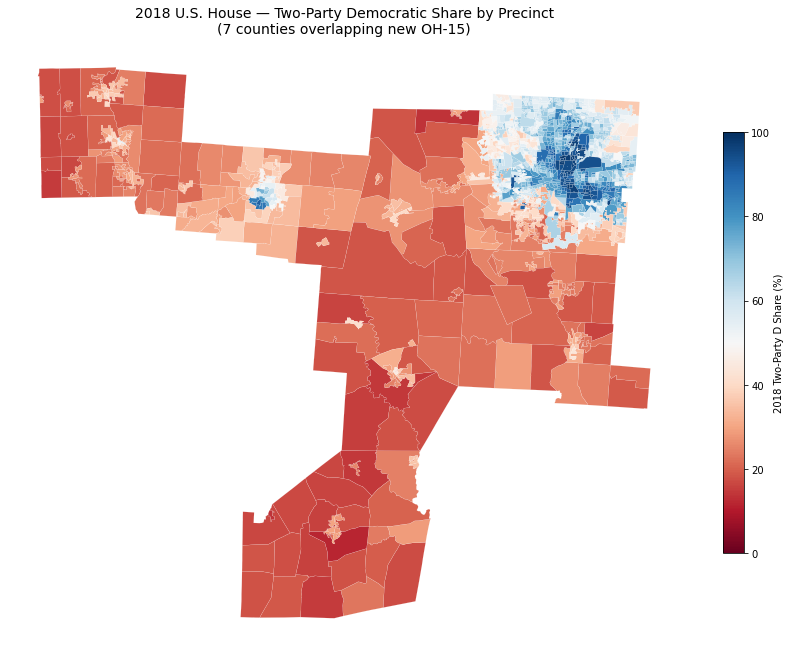

In [34]:
import matplotlib.pyplot as plt

# Compute two-party D-share per precinct
gdf = placed_all.copy()
gdf["dshare"] = gdf["H18_DEM"] / (gdf["H18_DEM"] + gdf["H18_REP"]) * 100

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf.plot(
    column="dshare",
    cmap="RdBu",          # red = low D-share (R), blue = high D-share (D)
    vmin=0, vmax=100,     # fix scale 0-100 so 50 is the neutral midpoint
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "2018 Two-Party D Share (%)", "shrink": 0.5},
    ax=ax,
)
ax.set_title("2018 U.S. House — Two-Party Democratic Share by Precinct\n(7 counties overlapping new OH-15)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

In [35]:
import matplotlib.pyplot as plt

# in_oh15 is block-level, already clipped to the district. But does it have geometry?
print("in_oh15 columns:", in_oh15.columns.tolist())
print("Has geometry?", "geometry" in in_oh15.columns)
print("CRS:", in_oh15.crs if hasattr(in_oh15, "crs") else "not a GeoDataFrame")

in_oh15 columns: ['GEOID20', 'P0010001', 'centroid', 'index_right', 'cty3', 'pname', 'NAME18', 'GEOID18', 'H18_DEM', 'H18_REP', 'H18_OTH', 'H18_TOT', 'pop_share', 'blk_DEM', 'blk_REP', 'blk_OTH', 'blk_TOT']
Has geometry? False
CRS: epsg:4269


OH-15 blocks with geometry: 16,658


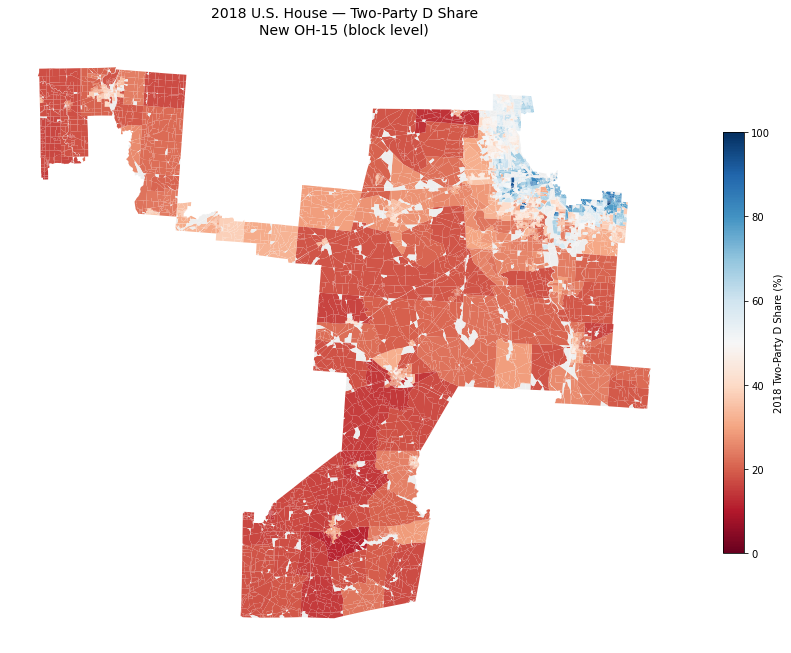

In [36]:
import matplotlib.pyplot as plt

# Attach block polygons back to in_oh15 by GEOID20 (blocks has the geometry)
oh15_geo = blocks[["GEOID20","geometry"]].merge(
    in_oh15[["GEOID20","blk_DEM","blk_REP","blk_TOT"]],
    on="GEOID20", how="inner"   # inner = only OH-15 blocks
)
oh15_geo = gpd.GeoDataFrame(oh15_geo, geometry="geometry", crs=blocks.crs)
print(f"OH-15 blocks with geometry: {len(oh15_geo):,}")

# Two-party D share per block (guard against 0-vote blocks)
denom = oh15_geo["blk_DEM"] + oh15_geo["blk_REP"]
oh15_geo["dshare"] = (oh15_geo["blk_DEM"] / denom * 100).where(denom > 0)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
oh15_geo.plot(
    column="dshare", cmap="RdBu", vmin=0, vmax=100,
    linewidth=0, legend=True,
    legend_kwds={"label": "2018 Two-Party D Share (%)", "shrink": 0.5},
    missing_kwds={"color": "#eeeeee"},   # 0-vote blocks in light gray
    ax=ax,
)
ax.set_title("2018 U.S. House — Two-Party D Share\nNew OH-15 (block level)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

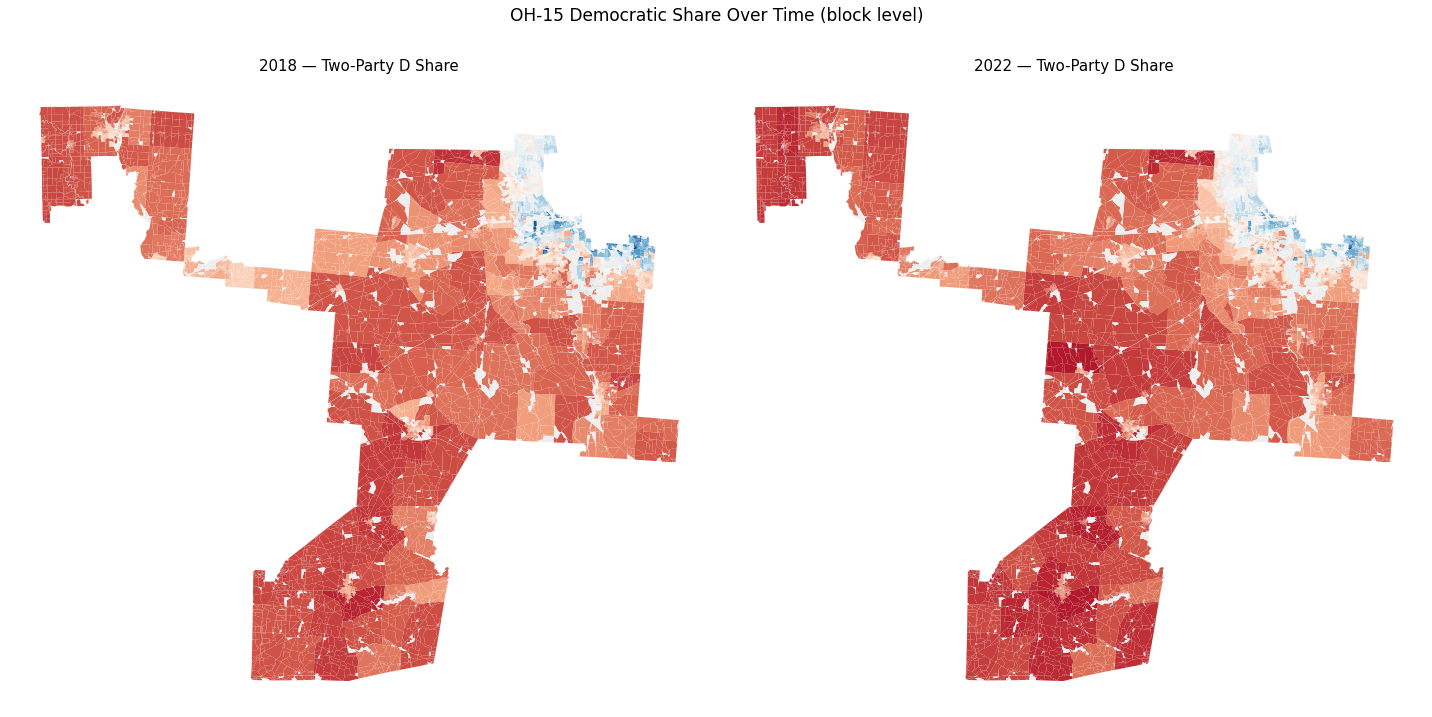

In [37]:
import matplotlib.pyplot as plt

# Load both years' block results
b18 = pd.read_csv(DATA / "derived_oh15_2018_blocks.csv", dtype={"GEOID20":str})
b22 = pd.read_csv(DATA / "derived_oh15_2022_blocks.csv", dtype={"GEOID20":str})

# Attach geometry to each
geo = blocks[["GEOID20","geometry"]]
g18 = gpd.GeoDataFrame(geo.merge(b18, on="GEOID20", how="inner"), geometry="geometry", crs=blocks.crs)
g22 = gpd.GeoDataFrame(geo.merge(b22, on="GEOID20", how="inner"), geometry="geometry", crs=blocks.crs)

# D-share for each
for g, dcol, rcol in [(g18,"dem_2018","rep_2018"), (g22,"dem_2022","rep_2022")]:
    d = g[dcol] + g[rcol]
    g["dshare"] = (g[dcol] / d * 100).where(d > 0)

fig, axes = plt.subplots(1, 2, figsize=(20, 11))
for ax, g, yr in [(axes[0], g18, "2018"), (axes[1], g22, "2022")]:
    g.plot(column="dshare", cmap="RdBu", vmin=0, vmax=100, linewidth=0,
           missing_kwds={"color":"#eeeeee"}, ax=ax)
    ax.set_title(f"{yr} — Two-Party D Share", fontsize=15)
    ax.axis("off")
plt.suptitle("OH-15 Democratic Share Over Time (block level)", fontsize=17, y=0.97)
plt.tight_layout()
plt.show()